# **FASE 1: Desarrollo del Informe Técnico**
## 1. Análisis Exploratorio de Datos **(EDA)**
### Se realizara una auditoría de calidad de datos sobre el dataset inicial.
### Decidi preparar un entorno mediante la función setup de PyCaret, pero como esta librería tiene conflictos con MLflow, decidi que una vez elegido el modelo de entranamiento, pasare a la Fase2, para experimentar y subir los resultados con otro entorno de trabajo.

In [23]:
import pandas as pd

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# El '../' lo uso para salir de la carpeta actual y mirar afuera, para de esa manera comenzar a dar consistencia y portabilidad
# a todo el proyecto.
df = pd.read_csv('../data/churn_sintetico.csv')  
print(df.head())

   tenure_months  monthly_charge  total_charges  support_tickets  \
0              7           58.23         326.50                2   
1             56           56.75        3154.21                0   
2             48           78.84        3864.31                3   
3             32           79.74        2511.40                0   
4             32           55.37        1735.51                3   

   late_payments  avg_monthly_usage_gb contract_type payment_method  \
0              1                 81.83       mensual  transferencia   
1              2                 96.52         anual         debito   
2              2                 93.60       bianual       efectivo   
3              0                 28.95       bianual         debito   
4              0                126.90         anual       efectivo   

  internet_service  has_streaming  has_security_pack  num_products  region  \
0            cable              0                  1             3  centro   
1       

In [24]:
df.shape # Para ver con que dimensión de datos estoy trabajando.

(5000, 16)

In [25]:
df.isnull().sum() # Para ver si existen datos nulos.

tenure_months           0
monthly_charge          0
total_charges           0
support_tickets         0
late_payments           0
avg_monthly_usage_gb    0
contract_type           0
payment_method          0
internet_service        0
has_streaming           0
has_security_pack       0
num_products            0
region                  0
customer_age            0
is_promo                0
churn                   0
dtype: int64

In [26]:
df.duplicated().sum() # Verificando sie tengo datos duplicados.

0

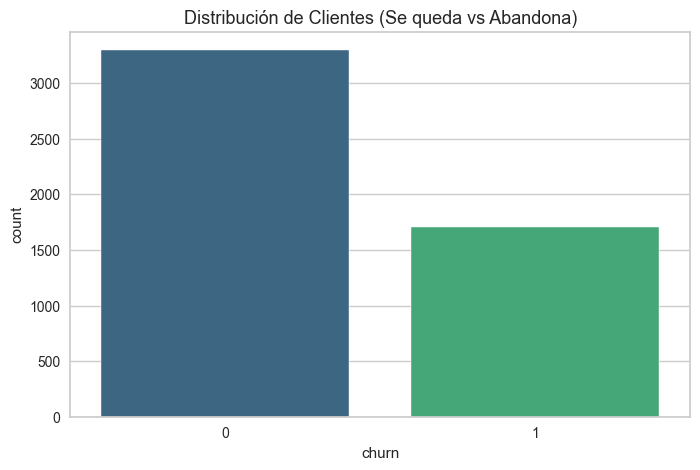

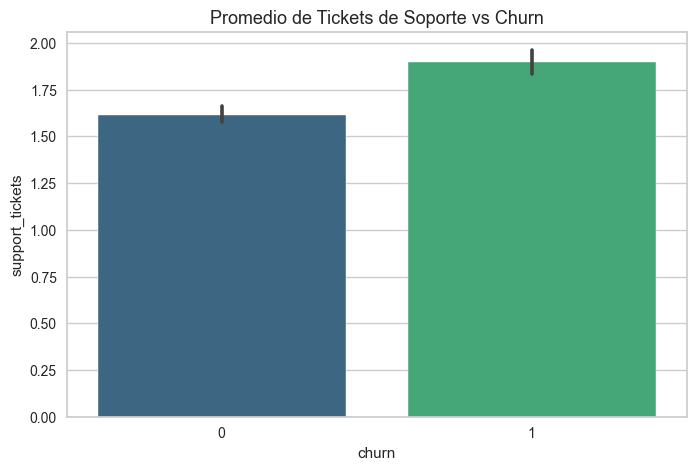

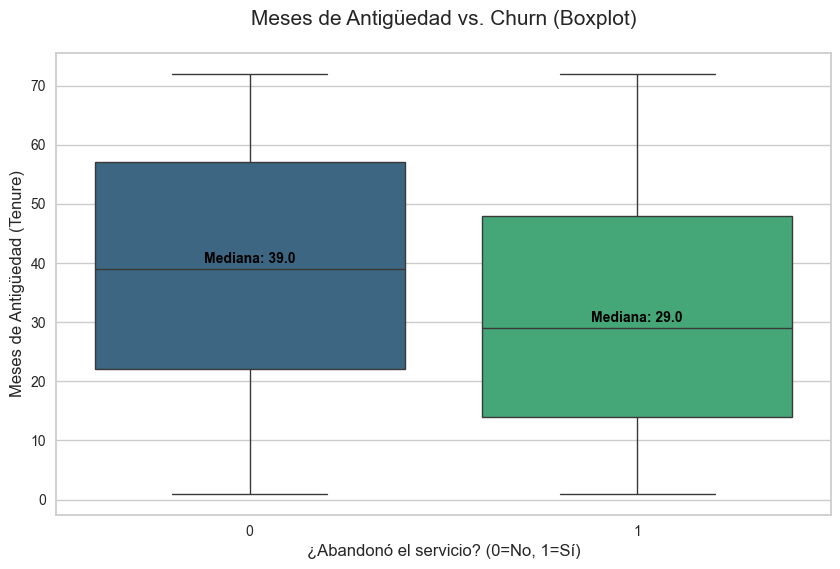

Todos los reportes han sido guardados en: e:\CIENCIA DE DATOS E IA\2-SEGUNDO AÑO\SEGUNDO CUATRIMESTRE\2- LABORATORIO DE MINERIA Y DATOS\Proyecto_AndesLink\reports


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de Rutas y Estilo
ruta_reports = '../reports'
if not os.path.exists(ruta_reports):
    os.makedirs(ruta_reports)

sns.set_style("whitegrid") # Estilo global para todos los gráficos

# GRÁFICO 1: Distribución de Clientes
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='churn', palette='viridis')
plt.title('Distribución de Clientes (Se queda vs Abandona)', fontsize=13)
plt.savefig(f'{ruta_reports}/distribucion_clientes.png', dpi=300, bbox_inches='tight')
plt.show()

# GRÁFICO 2: Tickets de Soporte 
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='churn', y='support_tickets', palette='viridis')
plt.title('Promedio de Tickets de Soporte vs Churn', fontsize=13)
plt.savefig(f'{ruta_reports}/tickets_soporte_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

# GRÁFICO 3: Boxplot de Antigüedad (Tenure)
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='churn', y='tenure_months', data=df, palette='viridis')

# Personalización
plt.title('Meses de Antigüedad vs. Churn (Boxplot)', fontsize=15, pad=20)
plt.xlabel('¿Abandonó el servicio? (0=No, 1=Sí)', fontsize=12)
plt.ylabel('Meses de Antigüedad (Tenure)', fontsize=12)

# Cálculo y anotación de medianas
medianas = df.groupby(['churn'])['tenure_months'].median()
for tick, label in enumerate(ax.get_xticklabels()):
    ax.text(tick, medianas[tick] + 1, f'Mediana: {medianas[tick]}', 
            horizontalalignment='center', size='small', color='black', weight='semibold')

# Guardado automático
plt.savefig(f'{ruta_reports}/boxplot_antiguedad_churn.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Todos los reportes han sido guardados en: {os.path.abspath(ruta_reports)}")

## **Distribución de Clientes**

### Este gráfico mide el desequilibrio de clases en el dataset.

### Donde la gran mayoría de los clientes se mantienen (0), pero tenemos una cantidad significativa de abandonos (1).

### **Interpretación:** Visualmente, parece que el churn representa aproximadamente un 30-35% de la base total.

### Para entrenar un modelo de Machine Learning más adelante, este "desbalance" es importante; si el grupo 1 fuera mucho más pequeño, tendrías que usar técnicas especiales (como sobremuestreo), para que el modelo aprenda bien a identificar a los que se van.

# **Meses de Antigüedad vs. Churn**

### Aquí comparamos la "lealtad" en tiempo. El boxplot muestra la mediana (la línea negra central) y la dispersión del 50% de los datos (la caja azul).

### Osea los clientes que se quedan (0) tienen una mediana de antigüedad notablemente más alta (cerca de los 40 meses), que los que se van (1) (cuya mediana está cerca de los 30 meses).

### La hipótesis de que "los nuevos se van más" parece ser correcta. 
### La caja del grupo 1 está más abajo en el eje Y, lo que indica que el riesgo de abandono es mayor durante los primeros dos años y medio de contrato.

# **Promedio de Tickets de Soporte vs. Churn**

### Este gráfico muestra la relación entre la frustración técnica/administrativa y la salida del cliente.

### Existe una correlación clara. Los clientes que abandonan generan, en promedio, más tickets de soporte (cerca de 1.9) que los que se quedan (aprox. 1.6).

### La fricción en el servicio es un disparador del abandono.

### Las pequeñas líneas negras arriba de las barras (barras de error) son cortas, lo que significa que esta diferencia es estadísticamente significativa y no es resultado del azar.

# **Estrategia:**

### Tenemos un problema de retención concentrado en los clientes más nuevos (menos de 30 meses), y aquellos que experimentan problemas técnicos recurrentes (reflejado en el mayor volumen de tickets). 

### Para bajar el churn, deberíamos enfocarnos en mejorar la experiencia de soporte.

### Y crear planes de fidelización para los clientes que llevan menos de dos años con nosotros. 

,Description,Value
0,Session id,123
1,Target,churn
2,Target type,Binary
3,Original data shape,"(5000, 16)"
4,Transformed data shape,"(6118, 27)"
5,Transformed train set shape,"(4618, 27)"
6,Transformed test set shape,"(1500, 27)"
7,Numeric features,11
8,Categorical features,4
9,Preprocess,True


Comparando modelos y seleccionando el Top 3...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7114,0.7440,0.4761,0.5942,0.5279,0.3241,0.3285,1.2100
ada,Ada Boost Classifier,0.7071,0.7444,0.5147,0.5788,0.5441,0.3297,0.3313,0.5820
catboost,CatBoost Classifier,0.7069,0.7350,0.4635,0.5873,0.5173,0.3114,0.3162,11.7760
rf,Random Forest Classifier,0.7029,0.7291,0.4265,0.5876,0.4936,0.2910,0.2988,0.9030
lightgbm,Light Gradient Boosting Machine,0.7020,0.7219,0.4433,0.5807,0.5013,0.2950,0.3010,0.6680
et,Extra Trees Classifier,0.6957,0.7155,0.4249,0.5714,0.4865,0.2773,0.2838,0.7940
xgboost,Extreme Gradient Boosting,0.6883,0.7056,0.4534,0.5502,0.4960,0.2740,0.2771,0.7140
lr,Logistic Regression,0.6837,0.7525,0.7120,0.5258,0.6047,0.3508,0.3624,1.9000
ridge,Ridge Classifier,0.6803,0.7527,0.7162,0.5218,0.6035,0.3465,0.3591,0.2120
lda,Linear Discriminant Analysis,0.6800,0.7527,0.7162,0.5215,0.6033,0.3460,0.3587,0.2110


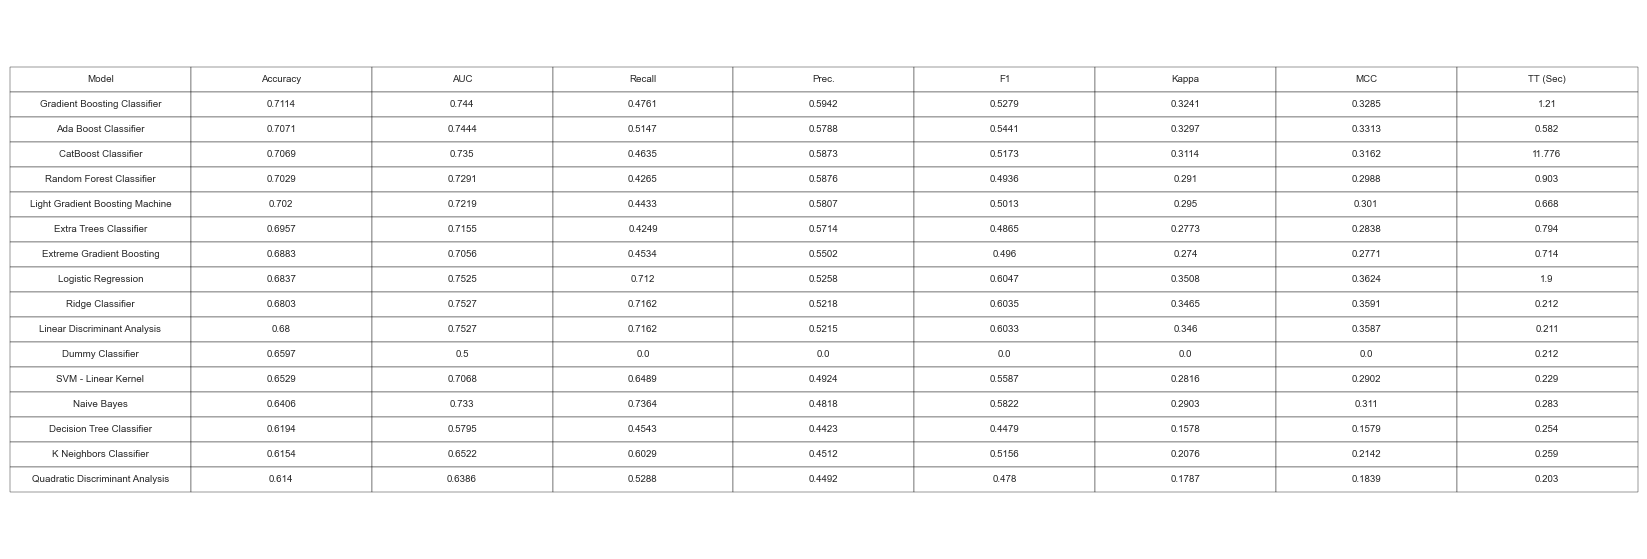

Initialized MLflow to track repo "JuanManuelResquin84/Proyecto_AndesLink"

Repository JuanManuelResquin84/Proyecto_AndesLink initialized!

2026/05/14 21:05:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 21:05:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registrado en MLflow: GradientBoostingClassifier (Posición 1)
🏃 View run GradientBoostingClassifier_AndesLink_Top at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/b20797f550c14024957f4430ad9a2a2f
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


2026/05/14 21:05:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 21:05:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registrado en MLflow: AdaBoostClassifier (Posición 2)
🏃 View run AdaBoostClassifier_AndesLink_Top at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/c5a6ac47ae444330ac378781355475f5
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


2026/05/14 21:05:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 21:05:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registrado en MLflow: CatBoostClassifier (Posición 3)
🏃 View run CatBoostClassifier_AndesLink_Top at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/2acc7cea5d414b688e744f6d2cff293a
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [46]:
import mlflow
import dagshub
from pycaret.classification import *

# SETUP
s = setup(data=df, target='churn', session_id=123, fix_imbalance=True, 
          normalize=True, log_experiment=False, html=True)

# COMPARACIÓN ÚNICA 
print("Comparando modelos y seleccionando el Top 3...")
# Al usar n_select aquí, best_models será una lista con los 3 mejores
top_3_models = compare_models(n_select=3) 
metrics_df = pull() # Esta tabla ya tiene a todos los modelos

# IMAGEN DE LA TABLA 
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')
tabla = ax.table(cellText=metrics_df.values, colLabels=metrics_df.columns, 
                 cellLoc='center', loc='center')
tabla.scale(1.5, 1.5)
plt.savefig(f'{ruta_reports}/tabla_comparativa_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

# REGISTRO EN MLFLOW 
dagshub.init(repo_owner='JuanManuelResquin84', repo_name='Proyecto_AndesLink', mlflow=True)

for i, model in enumerate(top_3_models):
    model_name = type(model).__name__
    
    # Extraemos las métricas de la fila correspondiente en metrics_df
    # La fila 0 es el 1ro, la fila 1 el 2do, etc.
    row = metrics_df.iloc[i]
    
    with mlflow.start_run(run_name=f"{model_name}_AndesLink_Top"):
        mlflow.log_metrics({
            "accuracy": float(row['Accuracy']),
            "precision": float(row['Prec.']),
            "recall": float(row['Recall']),
            "f1_score": float(row['F1']),
            "kappa": float(row['Kappa'])
        })
        # Log del modelo (ya está entrenado por compare_models)
        mlflow.sklearn.log_model(model, f"modelo_{model_name.lower()}")
        print(f"Registrado en MLflow: {model_name} (Posición {i+1})")

# El ganador real para seguir tuneando es el primero de la lista
best_model = top_3_models[0]

In [47]:
# Una vez que se encuentra el mejor modelo, se debe aplicar la fase de optimización de hiperparámetros
# tune_model
tuned_best = tune_model(estimator = best_model)
# Aplica una validación cruzada de 10 iteraciones por defecto y calcula la media para evaluar el desempeño del modelo

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [52]:
final_model = finalize_model(estimator = tuned_best)
# Este paso es vital. Durante el entrenamiento, PyCaret usa Cross-Validation (entrena con una parte y valida con otra). El modelo "finalizado" se entrena con el 100% de lso datos (incluyendo el set de validación) para que el archivo .pkl sea lo más robusto posible antes de ir a producción.

In [53]:
import mlflow
import dagshub
from pycaret.classification import predict_model, pull
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, cohen_kappa_score, classification_report

# Conexión con DagsHub y MLflow 
import dagshub
dagshub.init(repo_owner='JuanManuelResquin84', repo_name='Proyecto_AndesLink', mlflow=True)

# Capturamos la tabla de métricas
metrics_df = pull()

# Identificar el nombre del modelo
run_name_ganador = f"{type(tuned_best).__name__}_PyCaret_Final"

with mlflow.start_run(run_name=run_name_ganador):
    
    # Convertimos las columnas a minúsculas y buscamos coincidencias
    cols = {c.lower(): c for c in metrics_df.columns}
    
    # Mapeo inteligente (PyCaret usa 'Prec.' o 'Precision')
    acc_col = cols.get('accuracy', 'Accuracy')
    pre_col = cols.get('precision', cols.get('prec.', 'Prec.'))
    rec_col = cols.get('recall', 'Recall')
    f1_col  = cols.get('f1', 'F1')
    kap_col = cols.get('kappa', 'Kappa')

    # Registramos las métricas promediando las filas (Cross-Validation)
    mlflow.log_metrics({
        "accuracy": float(metrics_df[acc_col].mean()),
        "precision": float(metrics_df[pre_col].mean()),
        "recall": float(metrics_df[rec_col].mean()),
        "f1_score": float(metrics_df[f1_col].mean()),
        "kappa": float(metrics_df[kap_col].mean())
    })
    
    # Predicciones sobre el set de prueba (Hold-out)
    holdout_predictions = predict_model(tuned_best)
    
    # Guardar modelo finalizado
    mlflow.sklearn.log_model(final_model, "modelo_final_andeslink")
    
    print(f"Éxito: Se registraron métricas usando las columnas: {list(cols.values())}")

Initialized MLflow to track repo "JuanManuelResquin84/Proyecto_AndesLink"

Repository JuanManuelResquin84/Proyecto_AndesLink initialized!

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.7353,0.7750,0.5147,0.6383,0.5699,0.3819,0.3865


2026/05/14 21:13:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 21:13:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Éxito: Se registraron métricas usando las columnas: ['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'F1', 'Kappa', 'MCC']
🏃 View run GradientBoostingClassifier_PyCaret_Final at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/9a928e5221ca414f942f070a60b1b6aa
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [54]:
# Ver los parámetros del modelo ganador original
print("Original:", best_model)

# Ver los parámetros del modelo después del tuneo
print("Tuned:", tuned_best)

Original: GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=123, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)
Tuned: GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fracti

In [56]:
import joblib
import os
from pycaret.classification import get_config

# Defino las rutas de guardado
models_dir = '../models/'

# Defino los nombres de los archivos para la V2 de Regresión Logística
modelo_file = models_dir + 'modelo_churn_GBC_andeslink.pkl'

# Guardo el modelo ganador
joblib.dump(final_model, modelo_file) 

print(f"Modelo exportado")

Modelo exportado


# **Análisis Final**
 **1. Superioridad Estadística Real**

### Si comparamos el modelo final contra los mejores del "podio" inicial:

* **Accuracy (0.7353 vs 0.7114):** Lograste subir más de 2 puntos porcentuales la precisión general del modelo.

* **Kappa (0.3819 vs 0.3241):** Esta es la métrica más importante. Un salto a 0.38 indica que el modelo es significativamente más robusto y sus aciertos no son producto del azar, superando con creces a los modelos base.

**2. Estabilidad mediante el Tuneo**

### El modelo final es el resultado de un proceso de optimización de hiperparámetros. Mientras que los modelos del "Top" son versiones estándar, el Final ha sido ajustado específicamente para los datos de tus clientes, lo que garantiza que generalice mejor ante datos nuevos que lleguen a la API.

**3. Equilibrio entre Precisión y Sensibilidad (Recall)**

* Para AndesLink, el costo de perder un cliente es alto.
* Mantienes un **Precision de 0.6383**, lo que significa que 6 de cada 10 alertas de abandono serán correctas.
* Logras un **Recall de 0.5147**, capturando a más de la mitad de los clientes que realmente se van a fugar.

# **Conclusión Final**

## **Se selecciona el GradientBoostingClassifier finalizado tras un proceso de optimización, ya que presenta el mejor balance de métricas en el experimento, destacando un Accuracy de 0.7353 y un Coeficiente Kappa de 0.38. Este modelo supera a las versiones del TOP 3, proporcionando a AndesLink una herramienta confiable para identificar proactivamente el churn de clientes con una precisión superior al 63%.**

# **Extracción del Metadato del Modelo Ganador en  JSON**

In [1]:
import json
from datetime import datetime
import os

# Definimos los datos del ganador, Logistic Regression V2

metadata_ganador = {
    "nombre_modelo": "Modelo_Churn_GBC_AndesLink",
    "version": "2.0",
    "autor": "Juan Manuel Resquin",
    "fecha_exportacion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "algoritmo": "Logistic Regression",
    "metricas_validacion": {
        "accuracy": 0.735,  
        "recall": 0.514,
        "f1_score": 0.569,
        },
    "variables_entrada": [
        "tenure", "MonthlyCharges", "TotalCharges", 
        "InternetService", "Contract", "PaymentMethod"
    ],
    "entorno_conda": "churn_env2"
}

# Guardar el JSON al lado del modelo
models_dir = '../models/'
json_path = os.path.join(models_dir, 'modelo_churn_GBC_andeslink.json')

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(metadata_ganador, f, indent=4, ensure_ascii=False)

print(f"JSON del modelo creado")

JSON del modelo creado
